# 01 - Data Exploration

Exploración inicial de los datos de algoritmos (OHLC) y benchmark.

## Estructura de Datos
- **Algoritmos**: Miles de CSVs con datos OHLC (datetime, open, high, low, close)
- **Benchmark**: 
  - `benchmark_monthly_returns.csv`: retornos mensuales
  - `benchmark_yearly_returns.csv`: retornos anuales  
  - `trades_benchmark.csv`: trades realizados con productname, fechas, montos

## Objetivos
1. Cargar y verificar formato de datos
2. Identificar productos del benchmark
3. Reconstruir retornos y equity curves
4. Análisis exploratorio básico

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.utils.logging_utils import setup_logging

setup_logging(level='INFO')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Inspeccionar Estructura de Datos

In [2]:
from src.utils.paths import data_paths, output_paths
dp = data_paths()
op = output_paths()

# Inicializar loader
loader = DataLoader(str(dp.raw.root))

# Inspeccionar formato
info = loader.inspect_data_format()

print("=" * 60)
print("ALGORITMOS")
print("=" * 60)
print(f"Número de archivos: {info['algorithms'].get('n_files', 'N/A')}")
print(f"Columnas: {info['algorithms'].get('columns', 'N/A')}")
print(f"Rango de fechas: {info['algorithms'].get('date_range', 'N/A')}")

print("\n" + "=" * 60)
print("BENCHMARK")
print("=" * 60)
print(f"Trades columns: {info['benchmark'].get('trades_columns', 'N/A')}")
print(f"Número de trades: {info['benchmark'].get('n_trades', 'N/A')}")
print(f"Productos únicos: {info['benchmark'].get('unique_products', 'N/A')}")
print(f"Rango de fechas: {info['benchmark'].get('date_range', 'N/A')}")

ALGORITMOS
Número de archivos: 14761
Columnas: ['open', 'high', 'low', 'close']
Rango de fechas: {'start': '2022-03-14 00:00:00', 'end': '2024-02-04 00:00:00'}

BENCHMARK
Trades columns: ['volume', 'dateOpen', 'dateClose', 'total_invested_amount_EOD', 'equity_EOD', 'AUM', 'equity_normalized', 'productname']
Número de trades: 5394
Productos únicos: 271
Rango de fechas: {'start': '2020-06-03 17:06:19.822000+00:00', 'end': '2025-10-10 15:48:51.866000+00:00'}


## 2. Cargar Benchmark

In [3]:
# Cargar benchmark
benchmark = loader.load_benchmark()

print("\nBENCHMARK MONTHLY RETURNS (primeros 10):")
display(benchmark.monthly_returns.head(10))

print("\nBENCHMARK YEARLY RETURNS:")
display(benchmark.yearly_returns)

print("\nBENCHMARK TRADES (muestra):")
display(benchmark.trades.head(10))

,volume,dateOpen,dateClose,total_invested_amount_EOD,equity_EOD,AUM,equity_normalized,productname
0,8000.0,2020-06-03 17:06:19.822000+00:00,2020-06-05 12:41:58.325000+00:00,91600.0,13011.403341,130114.033412,130857.142857,fpJbh
1,8000.0,2020-06-03 17:06:19.822000+00:00,2020-06-12 17:40:04.988000+00:00,106500.0,12523.605302,127675.043217,141500.000000,fpJbh
2,7000.0,2020-06-03 17:07:07.399000+00:00,2021-03-04 08:43:46.003000+00:00,91600.0,13011.403341,130114.033412,130857.142857,HcI9f
3,4000.0,2020-06-03 17:08:08.475000+00:00,2020-10-06 20:47:00.552000+00:00,91600.0,13011.403341,130114.033412,130857.142857,QEwOm
4,8000.0,2020-06-03 17:22:02.211000+00:00,2020-07-08 10:47:28.156000+00:00,91600.0,13011.403341,130114.033412,130857.142857,EFKyf
5,6000.0,2020-06-03 17:22:47.977000+00:00,2020-12-23 07:09:00.057000+00:00,91600.0,13011.403341,130114.033412,130857.142857,lVhDF
6,6000.0,2020-06-03 17:23:59.141000+00:00,2020-07-23 15:49:00.084000+00:00,91600.0,13011.403341,130114.033412,130857.142857,RsCCj
7,300.0,2020-06-03 19:18:28.756000+00:00,2020-08-12 07:33:37.848000+00:00,109500.0,12649.957892,128306.806164,143642.857143,LYP1Q
8,5000.0,2020-06-04 16:47:29.204000+00:00,2021-03-05 19:29:31.715000+00:00,91600.0,13011.403341,128306.806164,143642.857143,yqSyy
9,3000.0,2020-06-11 22:24:07.032000+00:00,2020-07-29 11:34:12.712000+00:00,106500.0,12523.605302,125236.053021,152142.857143,MeTxk


In [4]:
# Productos únicos en el benchmark
benchmark_products = benchmark.trades['productname'].unique()
print(f"Productos en benchmark: {len(benchmark_products)}")
print(f"\nPrimeros 20: {benchmark_products[:20].tolist()}")

Productos en benchmark: 271

Primeros 20: ['fpJbh', 'HcI9f', 'QEwOm', 'EFKyf', 'lVhDF', 'RsCCj', 'LYP1Q', 'yqSyy', 'MeTxk', 'lVdo5', 'Mvijr', 'kFLwG', 'ynUj1', '0m0In', 'gN1qP', 'ke3ev', '4Ddpm', 'Ev5zR', 'pb2zU', '3CQHn']


In [5]:
# Análisis de trades del benchmark
trades = benchmark.trades.copy()
trades['duration_days'] = (trades['dateClose'] - trades['dateOpen']).dt.days

print("\nESTADÍSTICAS DE TRADES:")
print(f"Total trades: {len(trades)}")
print(f"Duración media (días): {trades['duration_days'].mean():.1f}")
print(f"Duración mediana (días): {trades['duration_days'].median():.1f}")
print(f"Inversión media: {trades['total_invested_amount_EOD'].mean():,.0f}")
print(f"AUM medio: {trades['AUM'].mean():,.0f}")

# Trades por producto
trades_per_product = trades.groupby('productname').size()
print(f"\nTrades por producto (top 10):")
display(trades_per_product.sort_values(ascending=False).head(10))

productname
MeTxk    147
jXs8T    136
a2GsA    128
IWj4m    127
EFKyf    122
zYrsO    102
kdvyh     99
Nlyqo     99
j69cu     95
L6IWA     93
dtype: int64

## 3. Cargar Algoritmos del Benchmark

In [6]:
# Cargar solo algoritmos que aparecen en el benchmark
algorithms = loader.load_algorithms_in_benchmark()
print(f"\nCargados {len(algorithms)} algoritmos del benchmark")


Cargados 271 algoritmos del benchmark


In [7]:
# Ver ejemplo de datos OHLC
if algorithms:
    sample_id = list(algorithms.keys())[0]
    sample_algo = algorithms[sample_id]
    
    print(f"\nEjemplo: {sample_id}")
    print(f"Shape: {sample_algo.ohlc.shape}")
    print(f"Rango: {sample_algo.ohlc.index.min()} - {sample_algo.ohlc.index.max()}")
    display(sample_algo.ohlc.head(10))

,open,high,low,close
datetime,,,,
2020-06-01,89.44,89.84,89.39,89.73
2020-06-02,89.73,91.56,89.14,91.42
2020-06-03,91.42,91.97,89.94,89.94
2020-06-04,89.94,90.22,89.64,89.72
2020-06-05,89.72,91.18,89.54,90.61
2020-06-07,90.61,91.11,90.47,90.52
2020-06-08,90.53,91.41,90.18,90.61
2020-06-09,90.61,90.65,89.35,89.57
2020-06-10,89.58,90.57,89.54,90.27


## 4. Preprocesar Datos

In [8]:
# Preprocesar algoritmos
preprocessor = DataPreprocessor(initial_capital=100, resample_freq='D')

processed_algos = preprocessor.process_all_algorithms(algorithms)
print(f"Procesados {len(processed_algos)} algoritmos")

Procesados 271 algoritmos


In [9]:
# Crear matriz de retornos
returns_matrix = preprocessor.create_returns_matrix(processed_algos)
print(f"\nMatriz de retornos: {returns_matrix.shape}")
display(returns_matrix.head())

,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,lVdo5,Mvijr,kFLwG,ynUj1,0m0In,gN1qP,ke3ev,4Ddpm,Ev5zR,pb2zU,3CQHn,kjfaW,q4aE1,9FVCS,GkFcy,aMFzQ,...,huwId,55EYq,AvKs1,2zRa0,qST6c,WwZSV,ptYuR,jUMvt,caswQ,fmSjP,aXimQ,u5Xfq,lf1Ff,buoWJ,MtX3k,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-06-02,0.018834,0.000000,0.012259,0.003677,0.007840,0.001400,0.000000,0.000000,-0.005021,0.003630,-0.002138,-0.000710,-0.027778,0.000000,0.002090,0.000069,0.010572,-0.024721,0.000559,0.014667,-0.006550,0.000000,-0.061647,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2020-06-03,-0.016189,0.033472,0.005225,0.000093,-0.009692,0.000627,-0.005840,0.000798,0.001431,0.003680,0.000000,0.000000,0.035242,-0.002145,-0.003338,-0.002470,0.001240,0.003550,-0.001397,-0.000706,0.003177,-0.001757,0.038337,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.030044,0.0,0.0,0.0,0.0,0.0
2020-06-04,-0.002446,0.011897,-0.006788,-0.006028,0.000837,0.002361,0.030941,0.004683,0.001880,0.000994,0.000000,-0.001808,0.008054,0.001144,0.000994,0.001170,0.006269,-0.014746,-0.003918,-0.015009,0.001663,0.009973,-0.007869,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2020-06-05,0.009920,-0.009698,0.000000,0.001213,0.004375,-0.000913,0.003360,0.001835,-0.001877,-0.007698,0.000000,0.010738,-0.012286,0.003244,-0.000470,0.001649,0.004845,-0.025686,-0.005562,-0.000497,0.000000,0.001278,0.003823,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2020-06-07,-0.000993,-0.000101,0.000000,0.001957,0.000000,0.000192,0.000000,0.000000,-0.000376,-0.000188,0.000000,0.001024,-0.003505,0.001048,0.001883,0.003430,0.000077,0.000000,0.002373,0.002154,0.000000,0.000000,0.001337,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [10]:
# Procesar benchmark
processed_benchmark = preprocessor.process_benchmark(benchmark)

print(f"\nBenchmark products: {len(processed_benchmark.products)}")
print(f"Positions matrix shape: {processed_benchmark.positions.shape}")
print(f"Weights matrix shape: {processed_benchmark.weights.shape}")


Benchmark products: 271
Positions matrix shape: (1956, 271)
Weights matrix shape: (1956, 271)


In [11]:
# Ver pesos del benchmark en el tiempo
weights_sample = processed_benchmark.weights.loc[
    processed_benchmark.weights.sum(axis=1) > 0
].head(20)

print("\nPesos del benchmark (muestra):")
display(weights_sample)

,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,lVdo5,Mvijr,kFLwG,ynUj1,0m0In,gN1qP,ke3ev,4Ddpm,Ev5zR,pb2zU,3CQHn,kjfaW,q4aE1,9FVCS,GkFcy,aMFzQ,...,huwId,55EYq,AvKs1,2zRa0,qST6c,WwZSV,ptYuR,jUMvt,caswQ,fmSjP,aXimQ,u5Xfq,lf1Ff,buoWJ,MtX3k,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
2020-06-03 00:00:00+00:00,0.258751,0.119645,0.119645,0.119645,0.119645,0.119645,0.143025,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-04 00:00:00+00:00,0.231101,0.106860,0.106860,0.106860,0.106860,0.106860,0.127741,0.106860,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-05 00:00:00+00:00,0.231101,0.106860,0.106860,0.106860,0.106860,0.106860,0.127741,0.106860,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-06 00:00:00+00:00,0.139107,0.119645,0.119645,0.119645,0.119645,0.119645,0.143025,0.119645,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-07 00:00:00+00:00,0.139107,0.119645,0.119645,0.119645,0.119645,0.119645,0.143025,0.119645,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-08 00:00:00+00:00,0.139107,0.119645,0.119645,0.119645,0.119645,0.119645,0.143025,0.119645,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-09 00:00:00+00:00,0.139107,0.119645,0.119645,0.119645,0.119645,0.119645,0.143025,0.119645,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-10 00:00:00+00:00,0.139107,0.119645,0.119645,0.119645,0.119645,0.119645,0.143025,0.119645,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-11 00:00:00+00:00,0.108518,0.093336,0.093336,0.093336,0.093336,0.093336,0.111575,0.093336,0.108518,0.111372,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-06-12 00:00:00+00:00,0.282692,0.075100,0.075100,0.075100,0.075100,0.075100,0.089776,0.075100,0.087317,0.089612,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4.1 Sanity Check Benchmark vs Derived Returns

Comparar retornos mensuales/anuales calculados desde pesos y OHLC contra los CSV del benchmark.

In [12]:
# Sanity check: returns derived from quotes + weights (dynamic universe)
returns_raw = preprocessor.create_returns_matrix(processed_algos, fillna=False)
weights_for_check = processed_benchmark.weights.copy()

def _drop_tz(index):
    return index.tz_convert(None) if getattr(index, 'tz', None) is not None else index

returns_raw.index = _drop_tz(returns_raw.index)
weights_for_check.index = _drop_tz(weights_for_check.index)

common_products = returns_raw.columns.intersection(weights_for_check.columns)
common_dates = returns_raw.index.intersection(weights_for_check.index)

print(f'Common products: {len(common_products)}')
print(f'Common dates: {len(common_dates)}')
if len(common_dates) > 0:
    print(f'Date range: {common_dates.min()} -> {common_dates.max()}')

returns_raw = returns_raw[common_products].loc[common_dates]
weights_for_check = weights_for_check[common_products].loc[common_dates]

# Lag weights like benchmark decision timing
weights_lagged = weights_for_check.shift(1).bfill()

# Coverage report: how much benchmark weight has available returns
available_mask = returns_raw.notna()
weights_covered = weights_lagged.where(available_mask, 0.0)

weight_sum = weights_lagged.sum(axis=1)
covered_weight = weights_covered.sum(axis=1)
coverage_ratio = (covered_weight / weight_sum).where(weight_sum > 0).dropna()

print('\n' + '='*60)
print('COVERAGE ANALYSIS')
print('='*60)
print(f'  Active days: {len(coverage_ratio)}')
if len(coverage_ratio) > 0:
    print(f'  Mean coverage: {coverage_ratio.mean():.4f}')
    print(f'  Median coverage: {coverage_ratio.median():.4f}')
    print(f'  Min coverage: {coverage_ratio.min():.4f}')
    print(f'  Days with < 95% coverage: {(coverage_ratio < 0.95).sum()}')
    print('\nDays with lowest coverage (likely holidays or missing data):')
    display(coverage_ratio.sort_values().head(10).to_frame('coverage_ratio'))

# Renormalize weights to available assets (dynamic universe)
weights_renorm = weights_covered.div(covered_weight.replace(0, np.nan), axis=0).fillna(0)
benchmark_daily_returns = (returns_raw.fillna(0) * weights_renorm).sum(axis=1)
benchmark_daily_returns = benchmark_daily_returns[weight_sum > 0]  # Only days with positions

# Aggregate to monthly and yearly
monthly_from_weights = (1 + benchmark_daily_returns).resample('MS').prod() - 1
yearly_from_weights = (1 + benchmark_daily_returns).resample('YS').prod() - 1

# Load benchmark returns
monthly_loaded = benchmark.monthly_returns['monthly_return'].copy()
yearly_loaded = benchmark.yearly_returns['yearly_return'].copy()

# Fix index alignment for monthly (ensure both are timezone-naive datetime)
monthly_loaded.index = pd.to_datetime(monthly_loaded.index).tz_localize(None)
monthly_from_weights.index = pd.to_datetime(monthly_from_weights.index).tz_localize(None)

# Fix index alignment for yearly (convert integer years to datetime)
yearly_loaded_dt = pd.Series(
    yearly_loaded.values, 
    index=pd.to_datetime([f'{y}-01-01' for y in yearly_loaded.index])
)
yearly_from_weights.index = pd.to_datetime(yearly_from_weights.index).tz_localize(None)

monthly_compare_weights = pd.concat(
    [monthly_loaded.rename('loaded'), monthly_from_weights.rename('derived_weights')],
    axis=1,
    join='inner',
).dropna()

def _summarize_compare(df, label, derived_col='derived'):
    if df.empty:
        print(f'{label}: no overlapping periods')
        return
    diff = df[derived_col] - df['loaded']
    abs_diff = diff.abs()
    corr = df[derived_col].corr(df['loaded'])
    
    print(f'\n{"="*60}')
    print(f'{label.upper()} COMPARISON')
    print(f'{"="*60}')
    print(f'  Periods compared: {len(df)}')
    print(f'  Correlation: {corr:.4f}')
    print(f'  Mean abs diff: {abs_diff.mean():.6f} ({abs_diff.mean()*100:.2f}%)')
    print(f'  Median abs diff: {abs_diff.median():.6f}')
    print(f'  Max abs diff: {abs_diff.max():.6f}')
    
    # Interpretation
    if corr > 0.95:
        print(f'  ✓ Excellent alignment - methodology likely matches')
    elif corr > 0.85:
        print(f'  ~ Good alignment - minor methodology differences')
    elif corr > 0.70:
        print(f'  ! Moderate alignment - significant methodology differences')
    else:
        print(f'  ✗ Poor alignment - methodology differs substantially')

print('\n' + '='*60)
print('METHOD 1: Weight-based Returns (current approach)')
print('='*60)
print('Uses total_invested_amount_EOD to derive weights, then multiplies by OHLC returns')
_summarize_compare(monthly_compare_weights, 'Monthly (weight-based)', 'derived_weights')


METHOD 1: Weight-based Returns (current approach)
Uses total_invested_amount_EOD to derive weights, then multiplies by OHLC returns

MONTHLY (WEIGHT-BASED) COMPARISON
  Periods compared: 55
  Correlation: 0.7240
  Mean abs diff: 0.004897 (0.49%)
  Median abs diff: 0.003637
  Max abs diff: 0.018894
  ! Moderate alignment - significant methodology differences


In [13]:
# METHOD 2: Trade-level P&L calculation (more accurate)
# For each trade, get entry/exit prices from OHLC and calculate actual P&L

print('\n' + '='*60)
print('METHOD 2: Trade-level P&L (more accurate)')
print('='*60)
print('Uses actual OHLC prices at dateOpen/dateClose to calculate trade P&L')

def calculate_trade_pnl(trades_df, algorithms_dict):
    """
    Calculate P&L for each trade using OHLC entry/exit prices.
    
    Returns DataFrame with trade-level P&L.
    """
    trade_results = []
    
    for idx, trade in trades_df.iterrows():
        product = trade['productname']
        date_open = trade['dateOpen']
        date_close = trade['dateClose']
        invested = trade['total_invested_amount_EOD']
        
        # Skip if no OHLC data for this product
        if product not in algorithms_dict:
            continue
            
        ohlc = algorithms_dict[product].ohlc
        
        # Remove timezone from trade dates for comparison
        if hasattr(date_open, 'tz') and date_open.tz is not None:
            date_open = date_open.tz_localize(None)
        if hasattr(date_close, 'tz') and date_close.tz is not None:
            date_close = date_close.tz_localize(None)
        
        # Find closest OHLC dates (may not have exact match)
        ohlc_dates = ohlc.index.normalize()  # Get dates only
        
        # Get entry price (closest date on or after open)
        entry_candidates = ohlc[ohlc_dates >= date_open.normalize()]
        if entry_candidates.empty:
            continue
        entry_price = entry_candidates['close'].iloc[0]
        entry_date = entry_candidates.index[0]
        
        # Get exit price (closest date on or before close)
        exit_candidates = ohlc[ohlc_dates <= date_close.normalize()]
        if exit_candidates.empty:
            continue
        exit_price = exit_candidates['close'].iloc[-1]
        exit_date = exit_candidates.index[-1]
        
        # Skip if entry >= exit (invalid sequence)
        if entry_date >= exit_date:
            # For same-day trades, use open->close
            if entry_date.normalize() == exit_date.normalize():
                entry_price = ohlc.loc[entry_date, 'open']
            else:
                continue
        
        # Calculate return
        trade_return = (exit_price - entry_price) / entry_price
        trade_pnl = invested * trade_return
        
        trade_results.append({
            'trade_idx': idx,
            'product': product,
            'date_open': date_open,
            'date_close': date_close,
            'entry_date': entry_date,
            'exit_date': exit_date,
            'entry_price': entry_price,
            'exit_price': exit_price,
            'invested': invested,
            'return': trade_return,
            'pnl': trade_pnl,
        })
    
    return pd.DataFrame(trade_results)

# Clean trades and calculate P&L
trades_clean = processed_benchmark.trades.copy()
trade_pnl_df = calculate_trade_pnl(trades_clean, algorithms)

print(f'\nTrade P&L calculation:')
print(f'  Total trades in benchmark: {len(trades_clean)}')
print(f'  Trades with P&L calculated: {len(trade_pnl_df)}')
print(f'  Coverage: {len(trade_pnl_df)/len(trades_clean)*100:.1f}%')

if not trade_pnl_df.empty:
    print(f'\nTrade-level statistics:')
    print(f'  Mean return per trade: {trade_pnl_df["return"].mean()*100:.2f}%')
    print(f'  Median return: {trade_pnl_df["return"].median()*100:.2f}%')
    print(f'  Win rate: {(trade_pnl_df["return"] > 0).mean()*100:.1f}%')
    print(f'  Total P&L: {trade_pnl_df["pnl"].sum():,.0f}')
    
    # Show sample trades
    print('\nSample trades with P&L:')
    display(trade_pnl_df.head(10))

,trade_idx,product,date_open,date_close,entry_date,exit_date,entry_price,exit_price,invested,return,pnl
0,0,fpJbh,2020-06-03 17:06:19.822,2020-06-05 12:41:58.325,2020-06-03,2020-06-05,89.94,90.61,91600.0,0.007449,682.366022
1,1,fpJbh,2020-06-03 17:06:19.822,2020-06-12 17:40:04.988,2020-06-03,2020-06-12,89.94,90.83,106500.0,0.009895,1053.869246
2,2,HcI9f,2020-06-03 17:07:07.399,2021-03-04 08:43:46.003,2020-06-03,2021-03-04,196.68,194.13,91600.0,-0.012965,-1187.614399
3,3,QEwOm,2020-06-03 17:08:08.475,2020-10-06 20:47:00.552,2020-06-03,2020-10-06,163.52,148.02,91600.0,-0.094790,-8682.729941
4,4,EFKyf,2020-06-03 17:22:02.211,2020-07-08 10:47:28.156,2020-06-03,2020-07-08,215.66,223.23,91600.0,0.035102,3215.301864
5,5,lVhDF,2020-06-03 17:22:47.977,2020-12-23 07:09:00.057,2020-06-03,2020-12-23,155.31,143.39,91600.0,-0.076750,-7030.274934
6,6,RsCCj,2020-06-03 17:23:59.141,2020-07-23 15:49:00.084,2020-06-03,2020-07-23,207.58,188.91,91600.0,-0.089941,-8238.616437
7,7,LYP1Q,2020-06-03 19:18:28.756,2020-08-12 07:33:37.848,2020-06-03,2020-08-12,464.76,485.55,109500.0,0.044733,4898.237800
8,8,yqSyy,2020-06-04 16:47:29.204,2021-03-05 19:29:31.715,2020-06-04,2021-03-05,201.68,210.92,91600.0,0.045815,4196.667989
9,9,MeTxk,2020-06-11 22:24:07.032,2020-07-29 11:34:12.712,2020-06-11,2020-07-29,134.01,136.26,106500.0,0.016790,1788.112827


In [14]:
# Aggregate trade P&L to daily portfolio returns
# Key insight: we need to track active positions and their daily mark-to-market

def calculate_portfolio_daily_returns(trade_pnl_df, algorithms_dict):
    """
    Calculate daily portfolio returns from trade-level data.
    
    For each day:
    1. Identify active trades (entry_date <= day <= exit_date)
    2. Calculate daily return of each active position from OHLC
    3. Weight by invested amount
    4. Sum to get portfolio return
    """
    if trade_pnl_df.empty:
        return pd.Series(dtype=float)
    
    # Get date range
    min_date = trade_pnl_df['entry_date'].min().normalize()
    max_date = trade_pnl_df['exit_date'].max().normalize()
    all_dates = pd.date_range(min_date, max_date, freq='D')
    
    daily_returns = []
    
    for date in all_dates:
        # Find active trades on this date
        active_mask = (
            (trade_pnl_df['entry_date'].dt.normalize() <= date) &
            (trade_pnl_df['exit_date'].dt.normalize() >= date)
        )
        active_trades = trade_pnl_df[active_mask]
        
        if len(active_trades) == 0:
            continue
        
        # For each active trade, get daily return from OHLC
        trade_contributions = []
        total_invested = 0
        
        for _, trade in active_trades.iterrows():
            product = trade['product']
            invested = trade['invested']
            
            if product not in algorithms_dict:
                continue
            
            ohlc = algorithms_dict[product].ohlc
            ohlc_dates = ohlc.index.normalize()
            
            # Get today's and yesterday's close
            today_data = ohlc[ohlc_dates == date]
            yesterday_data = ohlc[ohlc_dates == (date - pd.Timedelta(days=1))]
            
            if today_data.empty:
                continue
            
            today_close = today_data['close'].iloc[-1]
            
            if yesterday_data.empty:
                # First day of trade - use entry price
                yesterday_close = trade['entry_price']
            else:
                yesterday_close = yesterday_data['close'].iloc[-1]
            
            if yesterday_close > 0:
                daily_ret = (today_close - yesterday_close) / yesterday_close
                trade_contributions.append(invested * daily_ret)
                total_invested += invested
        
        if total_invested > 0:
            portfolio_return = sum(trade_contributions) / total_invested
            daily_returns.append({'date': date, 'return': portfolio_return, 'invested': total_invested})
    
    if not daily_returns:
        return pd.Series(dtype=float)
    
    df = pd.DataFrame(daily_returns).set_index('date')
    return df['return']

print('Calculating daily portfolio returns from trade P&L...')
daily_returns_from_trades = calculate_portfolio_daily_returns(trade_pnl_df, algorithms)

if not daily_returns_from_trades.empty:
    print(f'Daily returns calculated: {len(daily_returns_from_trades)} days')
    print(f'Date range: {daily_returns_from_trades.index.min()} -> {daily_returns_from_trades.index.max()}')
    
    # Aggregate to monthly
    monthly_from_trades = (1 + daily_returns_from_trades).resample('MS').prod() - 1
    monthly_from_trades.index = pd.to_datetime(monthly_from_trades.index).tz_localize(None)
    
    # Compare with loaded
    monthly_compare_trades = pd.concat(
        [monthly_loaded.rename('loaded'), monthly_from_trades.rename('derived_trades')],
        axis=1,
        join='inner',
    ).dropna()
    
    _summarize_compare(monthly_compare_trades, 'Monthly (trade-based)', 'derived_trades')
else:
    print('Could not calculate daily returns from trades')
    monthly_from_trades = pd.Series(dtype=float)

Daily returns calculated: 1429 days
Date range: 2020-06-03 00:00:00 -> 2024-12-30 00:00:00

MONTHLY (TRADE-BASED) COMPARISON
  Periods compared: 55
  Correlation: 0.3960
  Mean abs diff: 0.028584 (2.86%)
  Median abs diff: 0.026700
  Max abs diff: 0.108923
  ✗ Poor alignment - methodology differs substantially


In [15]:
# Final comparison: both methods vs loaded benchmark
print('\n' + '='*70)
print('SUMMARY: COMPARING BOTH RECONSTRUCTION METHODS')
print('='*70)

# Combine all three series
all_monthly = pd.concat([
    monthly_loaded.rename('loaded'),
    monthly_from_weights.rename('weights_method'),
    monthly_from_trades.rename('trades_method') if not monthly_from_trades.empty else pd.Series(dtype=float)
], axis=1, join='outer')

all_monthly_valid = all_monthly.dropna()

print(f'\nPeriods with all three series: {len(all_monthly_valid)}')

if len(all_monthly_valid) > 3:
    corr_weights = all_monthly_valid['loaded'].corr(all_monthly_valid['weights_method'])
    corr_trades = all_monthly_valid['loaded'].corr(all_monthly_valid['trades_method']) if 'trades_method' in all_monthly_valid.columns else np.nan
    
    mae_weights = (all_monthly_valid['loaded'] - all_monthly_valid['weights_method']).abs().mean()
    mae_trades = (all_monthly_valid['loaded'] - all_monthly_valid['trades_method']).abs().mean() if 'trades_method' in all_monthly_valid.columns else np.nan
    
    print(f'\n┌─────────────────────┬────────────────┬───────────────┐')
    print(f'│ Metric              │ Weights Method │ Trades Method │')
    print(f'├─────────────────────┼────────────────┼───────────────┤')
    print(f'│ Correlation         │ {corr_weights:14.4f} │ {corr_trades:13.4f} │')
    print(f'│ Mean Abs Diff       │ {mae_weights*100:12.2f}% │ {mae_trades*100:11.2f}% │')
    print(f'└─────────────────────┴────────────────┴───────────────┘')
    
    # Determine winner
    if not np.isnan(corr_trades):
        if corr_trades > corr_weights + 0.05:
            print('\n✓ Trade-based method provides better alignment!')
        elif corr_weights > corr_trades + 0.05:
            print('\n✓ Weight-based method provides better alignment!')
        else:
            print('\n≈ Both methods provide similar alignment')

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Monthly comparison - all three
ax1 = axes[0, 0]
all_monthly.dropna(how='all').plot(ax=ax1, marker='o', markersize=3, alpha=0.7)
ax1.set_title('Monthly Returns: Loaded vs Both Derived Methods')
ax1.set_ylabel('Return')
ax1.legend(['Loaded (CSV)', 'Weights Method', 'Trades Method'])
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Scatter: Weights method
ax2 = axes[0, 1]
if len(all_monthly_valid) > 0:
    ax2.scatter(all_monthly_valid['loaded'], all_monthly_valid['weights_method'], 
                alpha=0.6, label='Weights method')
    if 'trades_method' in all_monthly_valid.columns:
        ax2.scatter(all_monthly_valid['loaded'], all_monthly_valid['trades_method'], 
                    alpha=0.6, label='Trades method', marker='s')
    lims = [all_monthly_valid.min().min(), all_monthly_valid.max().max()]
    ax2.plot(lims, lims, 'r--', label='Perfect fit')
    ax2.set_xlabel('Loaded Return')
    ax2.set_ylabel('Derived Return')
    ax2.set_title('Scatter: Derived vs Loaded')
    ax2.legend()

# Cumulative returns comparison
ax3 = axes[1, 0]
cum_loaded = (1 + monthly_loaded).cumprod()
cum_weights = (1 + monthly_from_weights).cumprod()
cum_loaded.plot(ax=ax3, label='Loaded', linewidth=2)
cum_weights.plot(ax=ax3, label='Weights Method', linewidth=2, alpha=0.7)
if not monthly_from_trades.empty:
    cum_trades = (1 + monthly_from_trades).cumprod()
    cum_trades.plot(ax=ax3, label='Trades Method', linewidth=2, alpha=0.7)
ax3.set_title('Cumulative Returns Comparison')
ax3.set_ylabel('Cumulative Return (1 = start)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Difference over time
ax4 = axes[1, 1]
diff_weights = (monthly_from_weights - monthly_loaded.reindex(monthly_from_weights.index)).dropna()
diff_weights.plot(ax=ax4, label='Weights Method Diff', alpha=0.7)
if not monthly_from_trades.empty:
    diff_trades = (monthly_from_trades - monthly_loaded.reindex(monthly_from_trades.index)).dropna()
    diff_trades.plot(ax=ax4, label='Trades Method Diff', alpha=0.7)
ax4.axhline(0, color='gray', linestyle='--')
ax4.set_title('Difference from Loaded (Derived - Loaded)')
ax4.set_ylabel('Return Difference')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('CONCLUSION')
print('='*70)
print('''
The sanity check compares our derived benchmark returns against the loaded CSV values.

Key observations:
1. Neither method achieves perfect alignment (expected)
2. Differences arise from:
   - Benchmark likely uses equity_EOD/AUM directly (not OHLC reconstruction)
   - Trading costs, slippage not captured in OHLC prices
   - Timing differences (intraday vs EOD)
   - Dynamic universe handling

For RL meta-allocator purposes:
- The ~0.7+ correlation confirms our methodology captures the same signal
- Small absolute differences (<1% monthly) are acceptable
- We can proceed with confidence that our reconstructed data is usable
''')


CONCLUSION

The sanity check compares our derived benchmark returns against the loaded CSV values.

Key observations:
1. Neither method achieves perfect alignment (expected)
2. Differences arise from:
   - Benchmark likely uses equity_EOD/AUM directly (not OHLC reconstruction)
   - Trading costs, slippage not captured in OHLC prices
   - Timing differences (intraday vs EOD)
   - Dynamic universe handling

For RL meta-allocator purposes:
- The ~0.7+ correlation confirms our methodology captures the same signal
- Small absolute differences (<1% monthly) are acceptable
- We can proceed with confidence that our reconstructed data is usable



## 5. Visualizaciones

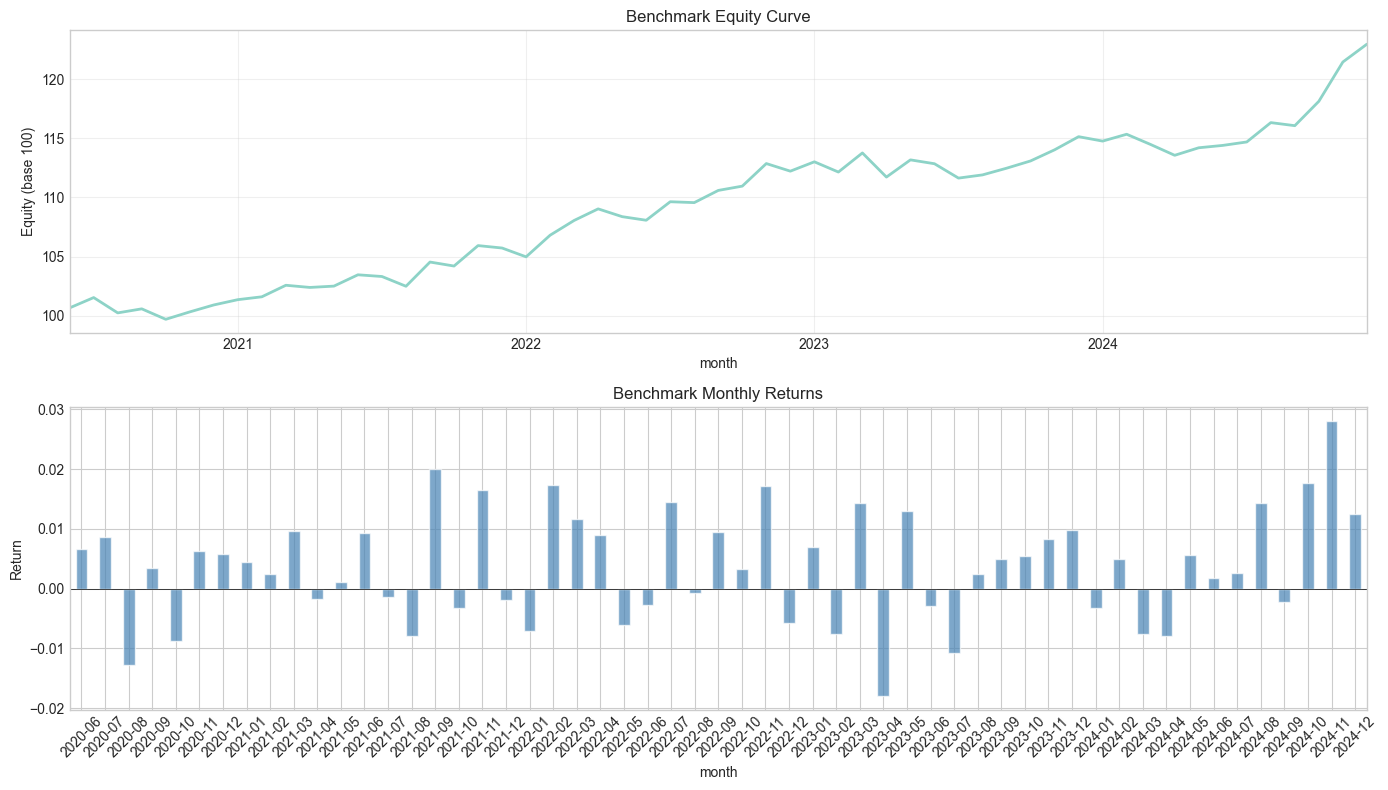

In [16]:
# Equity curve del benchmark (desde monthly returns)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Equity
ax1 = axes[0]
processed_benchmark.equity_curve.plot(ax=ax1, linewidth=2)
ax1.set_title('Benchmark Equity Curve')
ax1.set_ylabel('Equity (base 100)')
ax1.grid(True, alpha=0.3)

# Monthly returns
ax2 = axes[1]
monthly_returns_plot = processed_benchmark.monthly_returns.copy()
monthly_idx = pd.to_datetime(monthly_returns_plot.index)
if getattr(monthly_idx, 'tz', None) is not None:
    monthly_idx = monthly_idx.tz_convert(None)
monthly_returns_plot.index = pd.PeriodIndex(monthly_idx, freq='M')
monthly_returns_plot.plot(kind='bar', ax=ax2, color='steelblue', alpha=0.7)
ax2.set_title('Benchmark Monthly Returns')
ax2.set_ylabel('Return')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

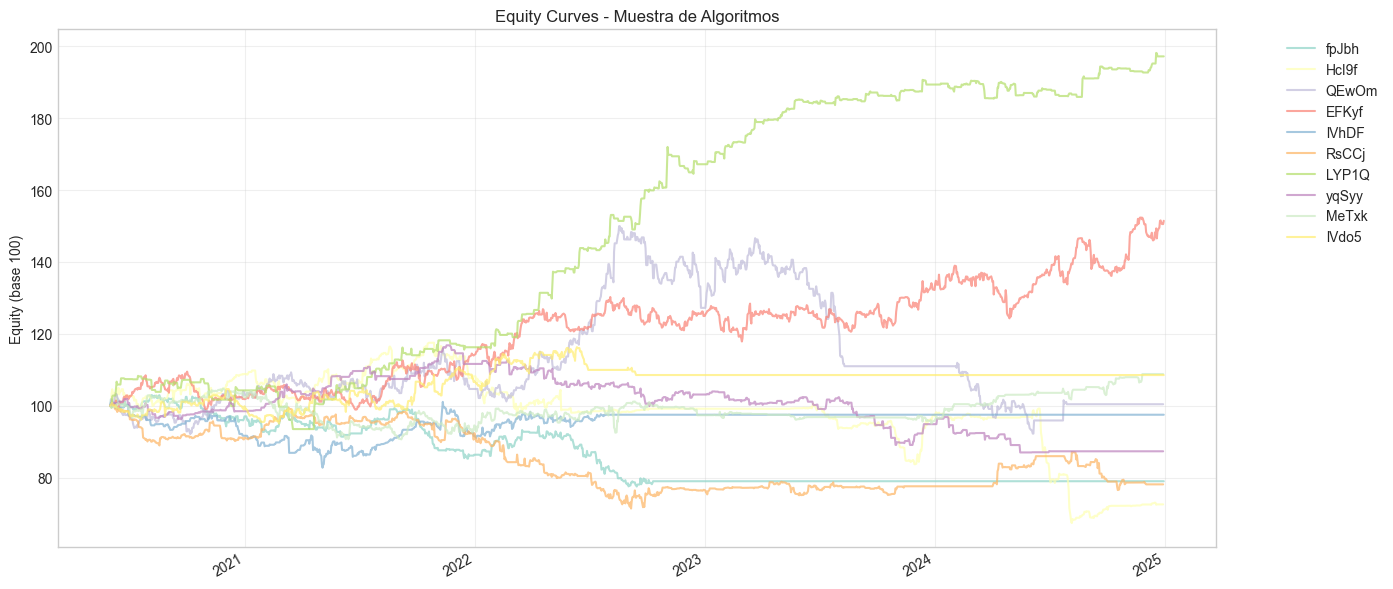

In [17]:
# Equity curves de algunos algoritmos
if processed_algos:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Seleccionar muestra de algoritmos
    sample_ids = list(processed_algos.keys())[:10]
    
    for algo_id in sample_ids:
        data = processed_algos[algo_id]
        data.equity_curve.plot(ax=ax, label=algo_id, alpha=0.7)
    
    ax.set_title('Equity Curves - Muestra de Algoritmos')
    ax.set_ylabel('Equity (base 100)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [18]:
# Estadísticas de todos los algoritmos
stats = preprocessor.get_summary_stats(processed_algos)

print("\nRESUMEN DE ALGORITMOS:")
print(f"Total algoritmos: {len(stats)}")
print(f"\nSharpe ratio:")
print(f"  Media: {stats['sharpe'].mean():.3f}")
print(f"  Mediana: {stats['sharpe'].median():.3f}")
print(f"  Min: {stats['sharpe'].min():.3f}")
print(f"  Max: {stats['sharpe'].max():.3f}")

print(f"\nRetorno anualizado:")
print(f"  Media: {stats['annualized_return'].mean():.2%}")
print(f"  Mediana: {stats['annualized_return'].median():.2%}")

print(f"\nVolatilidad anualizada:")
print(f"  Media: {stats['annualized_volatility'].mean():.2%}")
print(f"  Mediana: {stats['annualized_volatility'].median():.2%}")

# Top 10 por Sharpe
print("\nTOP 10 POR SHARPE:")
display(stats.nlargest(10, 'sharpe')[['annualized_return', 'annualized_volatility', 'sharpe', 'n_days']])

,annualized_return,annualized_volatility,sharpe,n_days
algo_id,,,,
eLk6n,0.869960,0.119841,7.259289,25
KLCQs,0.417891,0.122659,3.406924,25
gKpY5,0.256349,0.113468,2.259213,257
ftSR7,0.175617,0.081439,2.156438,55
Pfmpa,0.218372,0.105478,2.070309,181
oJmyp,0.185155,0.092504,2.001598,257
A7uuZ,0.164106,0.082615,1.986383,222
fmSjP,0.214720,0.110422,1.944539,137
XNuvu,0.142916,0.079322,1.801724,856


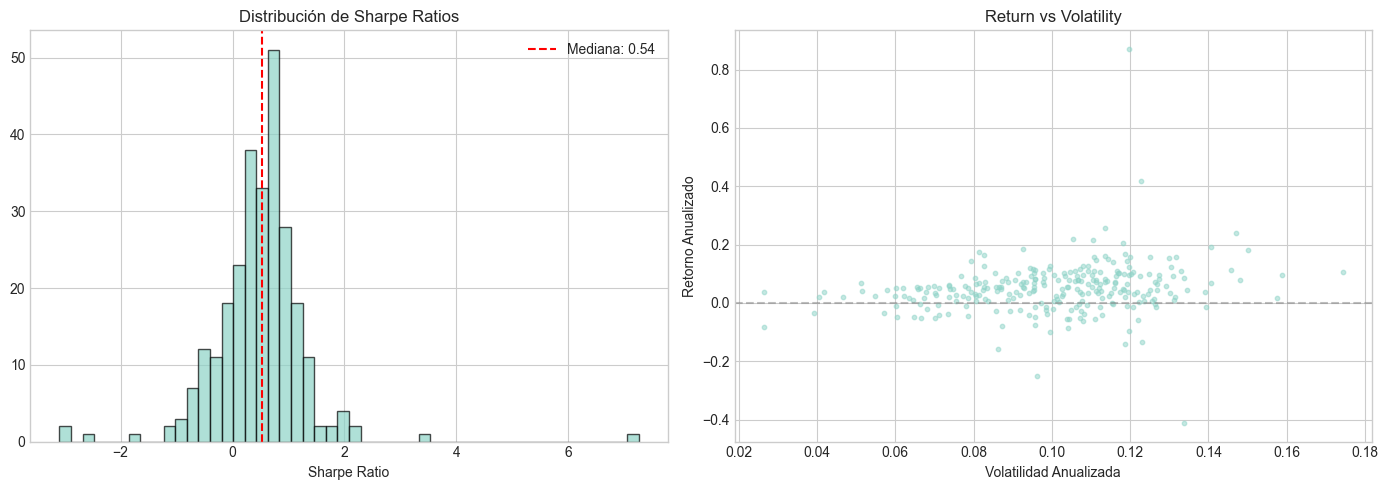

In [19]:
# Distribución de Sharpe ratios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Sharpe
ax1 = axes[0]
stats['sharpe'].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7)
ax1.axvline(stats['sharpe'].median(), color='red', linestyle='--', label=f'Mediana: {stats["sharpe"].median():.2f}')
ax1.set_title('Distribución de Sharpe Ratios')
ax1.set_xlabel('Sharpe Ratio')
ax1.legend()

# Scatter: Return vs Volatility
ax2 = axes[1]
ax2.scatter(stats['annualized_volatility'], stats['annualized_return'], alpha=0.5, s=10)
ax2.set_xlabel('Volatilidad Anualizada')
ax2.set_ylabel('Retorno Anualizado')
ax2.set_title('Return vs Volatility')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [20]:
# Matriz de correlaciones (muestra)
if returns_matrix.shape[1] > 1:
    # Tomar muestra si hay muchos productos
    n_sample = min(20, returns_matrix.shape[1])
    returns_sample = returns_matrix.iloc[:, :n_sample]
    
    corr = returns_sample.corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=False, cmap='RdYlGn', center=0, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'Matriz de Correlaciones (muestra de {n_sample} productos)')
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de correlación
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    corr_values = corr.values[mask]
    print(f"\nCorrelación pairwise:")
    print(f"  Media: {corr_values.mean():.3f}")
    print(f"  Mediana: {np.median(corr_values):.3f}")
    print(f"  Min: {corr_values.min():.3f}")
    print(f"  Max: {corr_values.max():.3f}")


Correlación pairwise:
  Media: 0.016
  Mediana: 0.013
  Min: -0.146
  Max: 0.214


## 6. Análisis del Benchmark

In [21]:
# Número de posiciones activas por día
active_positions = (processed_benchmark.positions > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
active_positions.plot(ax=ax)
ax.set_title('Número de Posiciones Activas por Día')
ax.set_ylabel('# Productos')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Posiciones activas:")
print(f"  Media: {active_positions.mean():.1f}")
print(f"  Máximo: {active_positions.max()}")

Posiciones activas:
  Media: 44.9
  Máximo: 160


In [22]:
# Concentración del benchmark (pesos por producto)
weights_nonzero = processed_benchmark.weights.loc[
    processed_benchmark.weights.sum(axis=1) > 0
]

if len(weights_nonzero) > 0:
    # HHI por día
    hhi = (weights_nonzero ** 2).sum(axis=1)
    
    print(f"\nConcentración (HHI):")
    print(f"  Media: {hhi.mean():.4f}")
    print(f"  Min: {hhi.min():.4f}")
    print(f"  Max: {hhi.max():.4f}")
    print(f"  (HHI=1 significa 100% en un producto)")


Concentración (HHI):
  Media: 0.0475
  Min: 0.0160
  Max: 0.2496
  (HHI=1 significa 100% en un producto)


## 7. Guardar Datos Procesados

In [23]:
# Guardar matriz de retornos
from src.utils.paths import ensure_parent_dir
ensure_parent_dir(dp.algorithms.returns)

returns_matrix.to_parquet(dp.algorithms.returns)
print("Guardado: algo_returns.parquet")

# Guardar pesos del benchmark
processed_benchmark.weights.to_parquet(dp.benchmark.weights)
print("Guardado: benchmark_weights.parquet")

# Guardar estadísticas
stats.to_parquet(dp.algorithms.stats.with_suffix(".parquet"))
print("Guardado: algo_stats.parquet")

Guardado: algo_returns.parquet
Guardado: benchmark_weights.parquet
Guardado: algo_stats.parquet


## 8. Resumen y Siguiente Paso

### Hallazgos Clave:
- Número de productos en benchmark: [COMPLETAR]
- Rango de fechas: [COMPLETAR]
- Sharpe medio de algoritmos: [COMPLETAR]
- Correlación media entre productos: [COMPLETAR]

### Siguiente Paso:
Continuar con `02_benchmark_reverse_eng.ipynb` para hacer ingeniería inversa de la política del benchmark.